# Generative AI for Personalized Marketing Copy

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd

from src import data_loader, evaluation, export_utils
from src.config import CUSTOMERS_CSV, PRODUCT_CATALOG_CSV, PURCHASE_HISTORY_CSV
from src.email_generator import EmailGenerator, generate_email_for_customer
from src.preprocessing import build_customer_profiles, segment_customers
from src.prompt_builder import build_prompt
from src.recommender import ProductRecommender

pd.set_option("display.max_colwidth", 120)

## 1. Load the data

In [4]:
customers_df = data_loader.load_customer_data(CUSTOMERS_CSV)
purchases_df = data_loader.load_purchase_data(PURCHASE_HISTORY_CSV)
catalog_df = data_loader.load_product_catalog(PRODUCT_CATALOG_CSV)

print(f"{len(customers_df)} customers, {len(purchases_df)} purchase records, {len(catalog_df)} catalog items")
customers_df.head()


40 customers, 164 purchase records, 30 catalog items


,customer_id,first_name,last_name,age,gender,city,state,country,email,signup_date
0,CUST0001,Ishita,Sharma,36,Female,Manchester,England,UK,ishita.sharma1@example.com,2025-12-16
1,CUST0002,Arjun,Gupta,53,Female,London,England,UK,arjun.gupta2@example.com,2024-12-05
2,CUST0003,Olivia,Verma,24,Female,Bengaluru,Karnataka,India,olivia.verma3@example.com,2025-12-06
3,CUST0004,Noah,Scott,54,Female,Bengaluru,Karnataka,India,noah.scott4@example.com,2024-07-29
4,CUST0005,Lucas,Taylor,47,Non-binary,Pune,Maharashtra,India,lucas.taylor5@example.com,2025-10-21


In [5]:
purchases_df.head()


,order_id,customer_id,product_name,category,price,quantity,purchase_date,rating
0,ORD00001,CUST0001,Portable Bluetooth Speaker,Electronics,1676.14,1,2025-10-20,5
1,ORD00002,CUST0002,Ikigai,Books,335.43,1,2025-04-04,5
2,ORD00003,CUST0002,Atomic Habits,Books,318.39,2,2025-08-04,5
3,ORD00004,CUST0002,Sapiens,Books,614.96,1,2024-09-11,5
4,ORD00005,CUST0002,Atomic Habits,Books,379.52,1,2026-04-12,4


## 2. A quick look at the data

In [6]:
customers_df.isna().sum()

customer_id    0
first_name     0
last_name      0
age            0
gender         0
city           0
state          0
country        0
email          0
signup_date    0
dtype: int64

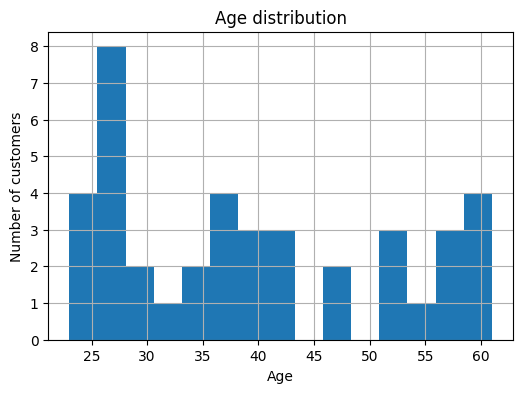

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
customers_df["age"].hist(bins=15, ax=ax)
ax.set_xlabel("Age")
ax.set_ylabel("Number of customers")
ax.set_title("Age distribution")
plt.show()

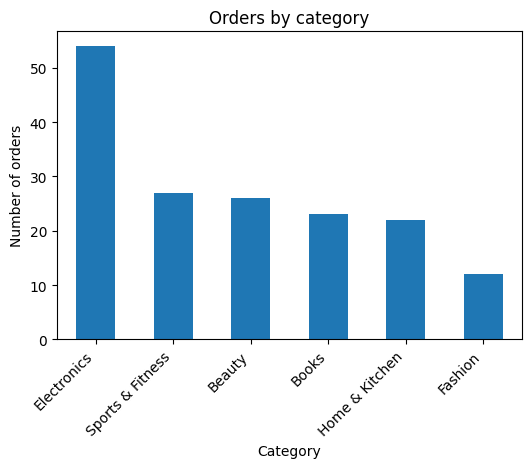

In [8]:
category_counts = purchases_df["category"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
category_counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Category")
ax.set_ylabel("Number of orders")
ax.set_title("Orders by category")
plt.xticks(rotation=45, ha="right")
plt.show()

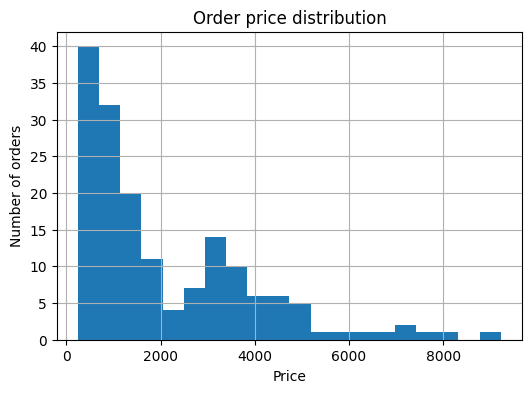

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
purchases_df["price"].hist(bins=20, ax=ax)
ax.set_xlabel("Price")
ax.set_ylabel("Number of orders")
ax.set_title("Order price distribution")
plt.show()

## 3. Merge customers + purchase history

In [10]:
profiles_df = build_customer_profiles(customers_df, purchases_df)
profiles_df[["customer_id", "first_name", "age_group", "favorite_category",
             "total_orders", "total_spent", "loyalty_tier"]].head(10)


,customer_id,first_name,age_group,favorite_category,total_orders,total_spent,loyalty_tier
0,CUST0001,Ishita,36-50,Electronics,1,1676.14,Bronze
1,CUST0002,Arjun,51-65,Books,4,1966.69,Silver
2,CUST0003,Olivia,18-25,Books,2,2136.41,Silver
3,CUST0004,Noah,51-65,Electronics,6,26622.52,Platinum
4,CUST0005,Lucas,36-50,Sports & Fitness,5,15960.27,Platinum
5,CUST0006,Aarav,36-50,Books,5,2586.86,Gold
6,CUST0007,Meera,36-50,Electronics,3,13628.88,Gold
7,CUST0008,Chris,36-50,Beauty,3,3869.20,Silver
8,CUST0009,Rohan,26-35,Fashion,2,5320.83,Silver
9,CUST0010,Isabella,51-65,Electronics,2,8452.38,Gold


In [11]:
profiles_df["loyalty_tier"].value_counts()

loyalty_tier
Platinum    16
Silver      12
Gold        11
Bronze       1
Name: count, dtype: int64

In [12]:
assert profiles_df["customer_id"].is_unique, "duplicate customer ids, merge went wrong somewhere"
assert profiles_df["total_spent"].min() >= 0

print("no duplicate ids, no negative spend - merge looks fine")

no duplicate ids, no negative spend - merge looks fine


## 4. Customer segments

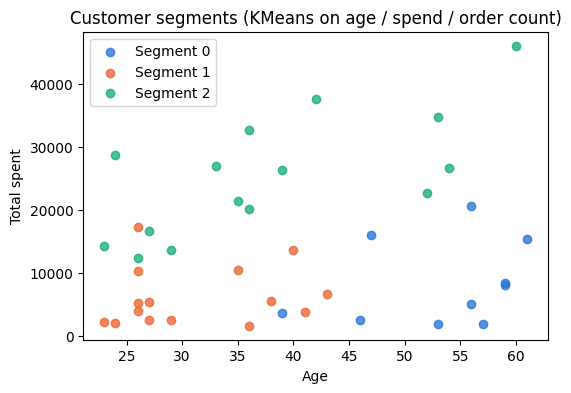

In [13]:
import matplotlib.pyplot as plt

segmented_df = segment_customers(profiles_df, n_clusters=3)
segment_colors = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}

fig, ax = plt.subplots(figsize=(6, 4))
for segment_id, group in segmented_df.groupby("segment"):
    ax.scatter(group["age"], group["total_spent"], label=f"Segment {segment_id}",
               color=segment_colors.get(segment_id, "#898781"), alpha=0.8)
ax.set_xlabel("Age")
ax.set_ylabel("Total spent")
ax.set_title("Customer segments (KMeans on age / spend / order count)")
ax.legend()
plt.show()


## 5. Product recommendations

In [14]:
recommender = ProductRecommender(catalog_df)

sample_customer = profiles_df.iloc[0]
recommended = recommender.recommend(
    purchased_products=sample_customer["purchased_products"],
    favorite_category=sample_customer["favorite_category"],
    top_n=3,
)

print(f"{sample_customer['first_name']} previously bought: {sample_customer['purchased_products']}")
print(f"Top picks for them: {recommended}")


Ishita previously bought: ['Portable Bluetooth Speaker']
Top picks for them: ['Smart Fitness Band', 'Wireless Earbuds Pro', '65W Fast Charger']


## 6. Build the prompt

In [15]:
sample_prompt = build_prompt(profiles_df.iloc[0], style="friendly", recommender=recommender)
print(sample_prompt)


You're a copywriter for Everdale, an online store, and you're good at making an email feel like it was written for one specific person instead of blasted out to a whole list.

Here's who this one's for: Ishita, 36-50, lives in Manchester. They mostly shop Electronics and the last thing they bought was Portable Bluetooth Speaker. 1 orders in so far, which puts them in our Bronze tier.

Style for this one: Friendly - warm, casual and conversational, like a friend giving a genuine recommendation. Contractions are fine, keep it light.

Work Smart Fitness Band into the email as a recommendation, and mention this offer: 5% off your next order.

Give me the output as six labeled parts, each starting on its own line (BODY can run a couple sentences). Don't add anything before or after, don't repeat a label, and don't explain what you're doing - just the six lines:

SUBJECT: under 12 words, something that'd actually make them want to open it
GREETING: one warm line, use their first name
BODY: 2

## 7. Generate emails with the LLM

In [ ]:
generator = EmailGenerator(max_new_tokens=220)

demo_customers = profiles_df.head(2).reset_index(drop=True)
demo_styles = ["friendly", "luxury"]

results = []
for (_, customer_row), style in zip(demo_customers.iterrows(), demo_styles):
    prompt = build_prompt(customer_row, style, recommender)
    sections = generate_email_for_customer(generator, prompt)
    full_text = " ".join(sections.values())
    sentiment = evaluation.sentiment_score(full_text)

    results.append({
        "customer_id": customer_row["customer_id"],
        "first_name": customer_row["first_name"],
        "city": customer_row["city"],
        "style": style,
        "subject": sections["SUBJECT"],
        "greeting": sections["GREETING"],
        "body": sections["BODY"],
        "recommendation": sections["RECOMMENDATION"],
        "offer": sections["OFFER"],
        "cta": sections["CTA"],
        "word_count": evaluation.word_count(full_text),
        "readability_score": evaluation.readability_score(full_text),
        "sentiment_label": sentiment["label"],
        "sentiment_polarity": sentiment["polarity"],
        "personalization_score": evaluation.personalization_score(sections, customer_row),
    })

results_df = pd.DataFrame(results)
results_df

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 195/195 [00:00<00:00, 6290.92it/s]
Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'top_p', 'pad_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


## 8. Read the results

In [ ]:
for record in results:
    print(record["style"], "-", record["first_name"], f"({record['city']})")
    print("Subject:", record["subject"])
    print(record["greeting"])
    print(record["body"])
    print("Recommendation:", record["recommendation"])
    print("Offer:", record["offer"])
    print("CTA:", record["cta"])
    print()

friendly - Ishita (Manchester)
Subject: Your Next Must-Have Fitness Companion Awaits!
Hey Ishita,
We noticed you're all about staying connected with that Portable Bluetooth Speaker. Just imagine keeping your tunes rolling as you jog or power through a workout.
Recommendation: That's why we think a Work Smart Fitness Band would be perfect for you - keeping you on track and in sync!
Offer: Plus, you're getting free shipping on your next purchase with us.
CTA: Discover your workout rhythm with us.

luxury - Arjun (London)
Subject: Enhance Your Reading Experience Like a Connoisseur
Dear Arjun,
We couldn't help but notice your passion for transformative reads, much like the way Atomic Habits has inspired you.
Recommendation: For a truly enriching journey, our curated selection of classics from renowned authors awaits you.
Offer: Plus, indulge in 10% off your next literary expedition.
CTA: Uncover timeless wisdom, Shop Now.



## 9. Evaluation metrics

In [ ]:
results_df[["style", "word_count", "readability_score", "sentiment_label", "personalization_score"]]


,style,word_count,readability_score,sentiment_label,personalization_score
0,friendly,73,74.0,Positive,25.0
1,luxury,57,45.4,Neutral,25.0


In [ ]:
results_df.groupby("style")[["word_count", "readability_score", "personalization_score"]].mean()


,word_count,readability_score,personalization_score
style,,,
friendly,73.0,74.0,25.0
luxury,57.0,45.4,25.0


In [ ]:
print("overall, across everything generated in this run:")
print("avg personalization score:", round(results_df["personalization_score"].mean(), 1))
print("avg readability score:", round(results_df["readability_score"].mean(), 1))
print("avg sentiment polarity:", round(results_df["sentiment_polarity"].mean(), 3))
print("avg word count:", round(results_df["word_count"].mean(), 1))

overall, across everything generated in this run:
avg personalization score: 25.0
avg readability score: 59.7
avg sentiment polarity: 0.212
avg word count: 65.0


## 10. Export to CSV

In [ ]:
output_path = export_utils.export_to_csv(results, filename="notebook_demo_emails.csv")
print(f"Saved to {output_path}")


Saved to E:\generative_AI_email\outputs\notebook_demo_emails.csv


## 11. Quick sanity checks

In [ ]:
sample = profiles_df.iloc[0]
rec = recommender.recommend(sample["purchased_products"], sample["favorite_category"], top_n=1)[0]
print(f"{sample['first_name']} already bought {sample['purchased_products']}, recommender picked {rec}")
assert rec not in sample["purchased_products"]

for record in results:
    assert record["word_count"] > 0
    assert 0 <= record["readability_score"] <= 100

print("recommendations don't repeat past purchases, and the metrics are all in sane ranges")

Ishita already bought ['Portable Bluetooth Speaker'], recommender picked Smart Fitness Band
recommendations don't repeat past purchases, and the metrics are all in sane ranges
